# Bitcoin Price Prediction: Advanced ML Models Comparison
## Comprehensive Predictive Modeling with Statistical, Traditional ML, Deep Learning & Ensemble Methods

This notebook implements and compares multiple predictive modeling approaches for Bitcoin price forecasting:
- **Statistical Models**: ARIMA, SARIMA, GARCH
- **Traditional ML**: Random Forest, XGBoost, LightGBM, CatBoost
- **Deep Learning**: LSTM, GRU, Transformer-based models
- **Ensemble Methods**: Stacking, Blending

All models are evaluated using proper time series cross-validation and compared on multiple metrics.

In [22]:
# Cell 1: Library Installation and Import Check

import sys
import subprocess
import importlib

# Required libraries
required_libraries = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'plotly': 'plotly',
    'scipy': 'scipy',
    'sklearn': 'scikit-learn',
    'statsmodels': 'statsmodels',
    'xgboost': 'xgboost',
    'lightgbm': 'lightgbm',
    'catboost': 'catboost',
    'tensorflow': 'tensorflow',
    'keras': 'keras',
}

def check_and_install_library(lib_name, package_name=None):
    """Check if library is installed, install if not available"""
    if package_name is None:
        package_name = lib_name
    
    try:
        importlib.import_module(lib_name)
        print(f"✓ {lib_name} is already installed")
        return True
    except ImportError:
        print(f"✗ {lib_name} is not installed. Installing {package_name}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
            print(f"✓ Successfully installed {package_name}")
            return True
        except subprocess.CalledProcessError:
            print(f"✗ Failed to install {package_name}. Please install manually.")
            return False

print("Checking required libraries...")
print("=" * 50)
missing_libs = []
for lib_name, package_name in required_libraries.items():
    if not check_and_install_library(lib_name, package_name):
        missing_libs.append(lib_name)

if missing_libs:
    print(f"\n⚠ Warning: Could not install: {', '.join(missing_libs)}")
else:
    print("\n✓ All required libraries are available!")
print("=" * 50)

Checking required libraries...
✓ numpy is already installed
✓ pandas is already installed
✓ matplotlib is already installed
✓ seaborn is already installed
✓ plotly is already installed
✓ scipy is already installed
✓ sklearn is already installed
✓ statsmodels is already installed
✓ xgboost is already installed
✓ lightgbm is already installed
✓ catboost is already installed
✓ tensorflow is already installed
✓ keras is already installed

✓ All required libraries are available!


In [23]:
# Cell 2: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Statistical modeling
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Utilities
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import joblib
from datetime import datetime

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

Libraries imported successfully!
TensorFlow version: 2.20.0
Keras version: 3.10.0


In [24]:
# Cell 3: Load Data

import os

def load_bitcoin_data():
    """Load Bitcoin price data from local or Kaggle environment"""
    kaggle_path = "/kaggle/input/bitcoin-12-years-price-january-2026/bitcoin.csv"
    local_path = "bitcoin.csv"
    
    if os.path.exists(kaggle_path):
        print(f"✓ Kaggle environment detected")
        df = pd.read_csv(kaggle_path)
    elif os.path.exists(local_path):
        print(f"✓ Local environment detected")
        df = pd.read_csv(local_path)
    else:
        raise FileNotFoundError("Dataset not found!")
    
    return df

df = load_bitcoin_data()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"\nData loaded: {len(df)} rows")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

✓ Local environment detected

Data loaded: 4134 rows
Date range: 2014-09-17 00:00:00 to 2026-01-10 00:00:00


In [25]:
# Cell 4: Data Preparation and Feature Engineering

# Calculate returns and features
df['Returns'] = df['Close'].pct_change()
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# Moving averages
for window in [7, 14, 30, 50, 200]:
    df[f'SMA_{window}'] = df['Close'].rolling(window=window).mean()
    df[f'EMA_{window}'] = df['Close'].ewm(span=window, adjust=False).mean()

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# MACD
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# Bollinger Bands
df['BB_Middle'] = df['Close'].rolling(window=20).mean()
bb_std = df['Close'].rolling(window=20).std()
df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)
df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)

# Volatility
df['Volatility'] = df['Returns'].rolling(window=30).std()

# Volume features
df['Volume_SMA'] = df['Volume'].rolling(window=30).mean()
df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA']

# Price features
df['High_Low_Ratio'] = df['High'] / df['Low']
df['Close_Open_Ratio'] = df['Close'] / df['Open']
df['Price_Range'] = df['High'] - df['Low']

# Time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Remove NaN values
df = df.dropna().reset_index(drop=True)

print(f"Data prepared: {len(df)} rows after feature engineering")
print(f"Features created: {len(df.columns)}")

Data prepared: 3935 rows after feature engineering
Features created: 35


## 1. Time Series Preprocessing & Stationarity Tests

In [26]:
# Cell 5: Stationarity Tests

def adf_test(timeseries):
    """Augmented Dickey-Fuller test for stationarity"""
    result = adfuller(timeseries.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'  {key}: {value}')
    if result[1] <= 0.05:
        print("✓ Series is stationary (reject null hypothesis)")
    else:
        print("✗ Series is non-stationary (fail to reject null hypothesis)")
    return result

def kpss_test(timeseries):
    """KPSS test for stationarity"""
    result = kpss(timeseries.dropna(), regression='c')
    print('KPSS Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[3].items():
        print(f'  {key}: {value}')
    if result[1] >= 0.05:
        print("✓ Series is stationary (fail to reject null hypothesis)")
    else:
        print("✗ Series is non-stationary (reject null hypothesis)")
    return result

print("=" * 60)
print("STATIONARITY TESTS ON CLOSE PRICE")
print("=" * 60)
print("\nADF Test:")
adf_result = adf_test(df['Close'])

print("\n" + "=" * 60)
print("STATIONARITY TESTS ON RETURNS")
print("=" * 60)
print("\nADF Test:")
adf_result_returns = adf_test(df['Returns'])

print("\nKPSS Test:")
kpss_result_returns = kpss_test(df['Returns'])

# For statistical models, we'll use returns (stationary) or differenced prices
print("\n" + "=" * 60)
print("CONCLUSION: Using Returns for Statistical Models")
print("=" * 60)

STATIONARITY TESTS ON CLOSE PRICE

ADF Test:
ADF Statistic: -0.7464250157428634
p-value: 0.8343552758807844
Critical Values:
  1%: -3.4320265580345004
  5%: -2.8622808115385583
  10%: -2.567164342737072
✗ Series is non-stationary (fail to reject null hypothesis)

STATIONARITY TESTS ON RETURNS

ADF Test:
ADF Statistic: -64.37912236504107
p-value: 0.0
Critical Values:
  1%: -3.432013338087558
  5%: -2.8622749717451534
  10%: -2.5671612338666803
✓ Series is stationary (reject null hypothesis)

KPSS Test:
KPSS Statistic: 0.2751091176595689
p-value: 0.1
Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739
✓ Series is stationary (fail to reject null hypothesis)

CONCLUSION: Using Returns for Statistical Models


In [27]:
# Cell 6: Train-Test Split (Time Series Aware)

# Use 80% for training, 20% for testing
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)
print(f"Training set: {len(train_df)} samples ({train_df['Date'].min()} to {train_df['Date'].max()})")
print(f"Test set: {len(test_df)} samples ({test_df['Date'].min()} to {test_df['Date'].max()})")
print(f"Training percentage: {len(train_df)/len(df)*100:.1f}%")
print(f"Test percentage: {len(test_df)/len(df)*100:.1f}%")

# Target variable: Next day's close price
train_target = train_df['Close'].values
test_target = test_df['Close'].values

# For statistical models: use returns
train_returns = train_df['Returns'].values[1:]  # Remove first NaN
test_returns = test_df['Returns'].values[1:]

TRAIN-TEST SPLIT
Training set: 3148 samples (2015-04-04 00:00:00 to 2023-11-15 00:00:00)
Test set: 787 samples (2023-11-16 00:00:00 to 2026-01-10 00:00:00)
Training percentage: 80.0%
Test percentage: 20.0%


In [28]:
# Cell 7: Evaluation Metrics Functions

def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive evaluation metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    
    # Directional accuracy
    if len(y_true) > 1:
        true_direction = np.diff(y_true) > 0
        pred_direction = np.diff(y_pred) > 0
        directional_accuracy = np.mean(true_direction == pred_direction) * 100
    else:
        directional_accuracy = 0
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2,
        'Directional_Accuracy': directional_accuracy
    }

def print_metrics(metrics, model_name):
    """Print metrics in formatted way"""
    print(f"\n{model_name} Performance Metrics:")
    print("-" * 50)
    print(f"MAE:  {metrics['MAE']:,.2f}")
    print(f"RMSE: {metrics['RMSE']:,.2f}")
    print(f"MAPE: {metrics['MAPE']:.2f}%")
    print(f"R2:   {metrics['R2']:.4f}")
    print(f"Directional Accuracy: {metrics['Directional_Accuracy']:.2f}%")

## 2. Statistical Models

### 2.1 ARIMA Model

In [29]:
# Cell 8: ARIMA Model

print("=" * 60)
print("ARIMA MODEL TRAINING")
print("=" * 60)

# Use returns for ARIMA (stationary series)
# We'll predict returns, then convert back to prices
train_returns_clean = train_returns[~np.isnan(train_returns)]
test_returns_clean = test_returns[~np.isnan(test_returns)]

try:
    # Auto ARIMA - try different orders
    best_aic = np.inf
    best_order = None
    best_model = None
    
    # Grid search for best parameters (limited for speed)
    for p in range(0, 3):
        for d in range(0, 2):
            for q in range(0, 3):
                try:
                    model = ARIMA(train_returns_clean, order=(p, d, q))
                    fitted_model = model.fit()
                    if fitted_model.aic < best_aic:
                        best_aic = fitted_model.aic
                        best_order = (p, d, q)
                        best_model = fitted_model
                except:
                    continue
    
    if best_model is not None:
        print(f"Best ARIMA order: {best_order}")
        print(f"Best AIC: {best_aic:.2f}")
        
        # Forecast
        forecast_steps = len(test_returns_clean)
        forecast = best_model.forecast(steps=forecast_steps)
        forecast_returns = forecast.values if hasattr(forecast, 'values') else forecast
        
        # Convert returns to prices
        last_train_price = train_df['Close'].iloc[-1]
        arima_predictions = [last_train_price]
        for ret in forecast_returns[:len(test_target)]:
            arima_predictions.append(arima_predictions[-1] * (1 + ret))
        arima_predictions = np.array(arima_predictions[1:])
        
        # Evaluate
        arima_metrics = calculate_metrics(test_target[:len(arima_predictions)], arima_predictions)
        print_metrics(arima_metrics, "ARIMA")
        
        arima_model = best_model
        arima_forecast = arima_predictions
    else:
        print("Failed to fit ARIMA model")
        arima_model = None
        arima_forecast = None
        arima_metrics = None
        
except Exception as e:
    print(f"ARIMA model error: {str(e)}")
    arima_model = None
    arima_forecast = None
    arima_metrics = None

ARIMA MODEL TRAINING
Best ARIMA order: (0, 0, 0)
Best AIC: -11855.36

ARIMA Performance Metrics:
--------------------------------------------------
MAE:  28,392.33
RMSE: 43,719.96
MAPE: 31.15%
R2:   -2.3933
Directional Accuracy: 51.59%


### 2.2 SARIMA Model

In [30]:
# Cell 9: SARIMA Model

print("=" * 60)
print("SARIMA MODEL TRAINING")
print("=" * 60)

try:
    # SARIMA with seasonal component
    # Try (1,1,1)(1,1,1,12) - monthly seasonality
    sarima_model = SARIMAX(train_returns_clean, 
                          order=(1, 1, 1),
                          seasonal_order=(1, 1, 1, 12),
                          enforce_stationarity=False,
                          enforce_invertibility=False)
    
    fitted_sarima = sarima_model.fit(disp=False)
    print(f"SARIMA AIC: {fitted_sarima.aic:.2f}")
    
    # Forecast
    forecast_steps = len(test_returns_clean)
    forecast = fitted_sarima.forecast(steps=forecast_steps)
    forecast_returns = forecast.values if hasattr(forecast, 'values') else forecast
    
    # Convert to prices
    last_train_price = train_df['Close'].iloc[-1]
    sarima_predictions = [last_train_price]
    for ret in forecast_returns[:len(test_target)]:
        sarima_predictions.append(sarima_predictions[-1] * (1 + ret))
    sarima_predictions = np.array(sarima_predictions[1:])
    
    # Evaluate
    sarima_metrics = calculate_metrics(test_target[:len(sarima_predictions)], sarima_predictions)
    print_metrics(sarima_metrics, "SARIMA")
    
except Exception as e:
    print(f"SARIMA model error: {str(e)}")
    fitted_sarima = None
    sarima_predictions = None
    sarima_metrics = None

SARIMA MODEL TRAINING
SARIMA AIC: -11665.15

SARIMA Performance Metrics:
--------------------------------------------------
MAE:  39,862.40
RMSE: 61,711.03
MAPE: 42.84%
R2:   -5.7606
Directional Accuracy: 50.96%


### 2.3 GARCH Model

In [31]:
# Cell 10: GARCH Model (Volatility Forecasting)

print("=" * 60)
print("GARCH MODEL TRAINING")
print("=" * 60)

try:
    # GARCH(1,1) model on returns
    garch_model = arch_model(train_returns_clean * 100, vol='Garch', p=1, q=1, rescale=False)
    fitted_garch = garch_model.fit(disp='off')
    print(f"GARCH Log Likelihood: {fitted_garch.loglikelihood:.2f}")
    
    # Forecast volatility (not price directly, but useful for risk)
    forecast_steps = len(test_returns_clean)
    garch_forecast = fitted_garch.forecast(horizon=forecast_steps)
    
    # For price prediction, use mean return + volatility forecast
    mean_return = train_returns_clean.mean()
    vol_forecast = np.sqrt(garch_forecast.variance.values[-1, :]) / 100
    
    # Simple price forecast using mean return and forecasted volatility
    last_train_price = train_df['Close'].iloc[-1]
    garch_predictions = [last_train_price]
    for i in range(min(forecast_steps, len(test_target))):
        # Use random walk with forecasted volatility
        pred_return = np.random.normal(mean_return, vol_forecast[i] if i < len(vol_forecast) else vol_forecast[-1])
        garch_predictions.append(garch_predictions[-1] * (1 + pred_return))
    garch_predictions = np.array(garch_predictions[1:])
    
    # Note: GARCH is primarily for volatility, not price prediction
    print("Note: GARCH model forecasts volatility. Price predictions are approximate.")
    garch_metrics = calculate_metrics(test_target[:len(garch_predictions)], garch_predictions)
    print_metrics(garch_metrics, "GARCH (Volatility-based)")
    
except Exception as e:
    print(f"GARCH model error: {str(e)}")
    print("Note: GARCH requires arch library. Install with: pip install arch")
    fitted_garch = None
    garch_predictions = None
    garch_metrics = None

GARCH MODEL TRAINING
GARCH Log Likelihood: -8281.99
Note: GARCH model forecasts volatility. Price predictions are approximate.

GARCH (Volatility-based) Performance Metrics:
--------------------------------------------------
MAE:  19,837.67
RMSE: 24,105.15
MAPE: 24.53%
R2:   -0.0315
Directional Accuracy: 47.13%


## 3. Traditional Machine Learning Models

In [32]:
# Cell 11: Prepare Features for ML Models

# Feature selection for ML models
feature_columns = ['Open', 'High', 'Low', 'Volume',
                  'SMA_7', 'SMA_14', 'SMA_30', 'SMA_50', 'SMA_200',
                  'EMA_7', 'EMA_14', 'EMA_30', 'EMA_50', 'EMA_200',
                  'RSI', 'MACD', 'MACD_Signal',
                  'BB_Middle', 'BB_Upper', 'BB_Lower',
                  'Volatility', 'Volume_SMA', 'Volume_Ratio',
                  'High_Low_Ratio', 'Close_Open_Ratio', 'Price_Range',
                  'Year', 'Month', 'DayOfWeek']

# Create lag features
lag_periods = [1, 2, 3, 5, 7]
for lag in lag_periods:
    df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)
    df[f'Returns_Lag_{lag}'] = df['Returns'].shift(lag)
    df[f'Volume_Lag_{lag}'] = df['Volume'].shift(lag)

feature_columns.extend([f'Close_Lag_{lag}' for lag in lag_periods])
feature_columns.extend([f'Returns_Lag_{lag}' for lag in lag_periods])
feature_columns.extend([f'Volume_Lag_{lag}' for lag in lag_periods])

# Remove rows with NaN from lag features
df_ml = df.dropna().reset_index(drop=True)

# Re-split with lag features
split_idx_ml = int(len(df_ml) * 0.8)
train_df_ml = df_ml.iloc[:split_idx_ml].copy()
test_df_ml = df_ml.iloc[split_idx_ml:].copy()

X_train = train_df_ml[feature_columns].values
y_train = train_df_ml['Close'].values
X_test = test_df_ml[feature_columns].values
y_test = test_df_ml['Close'].values

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Features: {len(feature_columns)}")

Training set: (3142, 44)
Test set: (786, 44)
Features: 44


### 3.1 Random Forest

In [33]:
# Cell 12: Random Forest Model

print("=" * 60)
print("RANDOM FOREST MODEL")
print("=" * 60)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_scaled)
rf_predictions_scaled = rf_model.predict(X_test_scaled)
rf_predictions = scaler_y.inverse_transform(rf_predictions_scaled.reshape(-1, 1)).ravel()

rf_metrics = calculate_metrics(y_test, rf_predictions)
print_metrics(rf_metrics, "Random Forest")

# Feature importance
rf_feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(rf_feature_importance.head(10))

RANDOM FOREST MODEL

Random Forest Performance Metrics:
--------------------------------------------------
MAE:  19,852.42
RMSE: 27,426.81
MAPE: 19.59%
R2:   -0.3413
Directional Accuracy: 58.09%

Top 10 Most Important Features:
    feature  importance
1      High      0.6480
2       Low      0.3456
9     EMA_7      0.0010
7    SMA_50      0.0008
4     SMA_7      0.0006
10   EMA_14      0.0006
8   SMA_200      0.0005
13  EMA_200      0.0005
11   EMA_30      0.0004
12   EMA_50      0.0004


### 3.2 XGBoost

In [34]:
# Cell 13: XGBoost Model

print("=" * 60)
print("XGBOOST MODEL")
print("=" * 60)

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train_scaled,
              eval_set=[(X_test_scaled, y_test_scaled)],
              verbose=False)

xgb_predictions_scaled = xgb_model.predict(X_test_scaled)
xgb_predictions = scaler_y.inverse_transform(xgb_predictions_scaled.reshape(-1, 1)).ravel()

xgb_metrics = calculate_metrics(y_test, xgb_predictions)
print_metrics(xgb_metrics, "XGBoost")

# Feature importance
xgb_feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(xgb_feature_importance.head(10))

XGBOOST MODEL

XGBoost Performance Metrics:
--------------------------------------------------
MAE:  20,685.76
RMSE: 28,379.88
MAPE: 20.48%
R2:   -0.4362
Directional Accuracy: 71.46%

Top 10 Most Important Features:
        feature  importance
1          High      0.5349
2           Low      0.3671
29  Close_Lag_1      0.0662
9         EMA_7      0.0149
30  Close_Lag_2      0.0109
31  Close_Lag_3      0.0027
18     BB_Upper      0.0009
4         SMA_7      0.0003
0          Open      0.0003
10       EMA_14      0.0002


### 3.3 LightGBM

In [35]:
# Cell 14: LightGBM Model

print("=" * 60)
print("LIGHTGBM MODEL")
print("=" * 60)

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train_scaled, y_train_scaled,
              eval_set=[(X_test_scaled, y_test_scaled)],
              eval_metric='rmse',
              callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])

lgb_predictions_scaled = lgb_model.predict(X_test_scaled)
lgb_predictions = scaler_y.inverse_transform(lgb_predictions_scaled.reshape(-1, 1)).ravel()

lgb_metrics = calculate_metrics(y_test, lgb_predictions)
print_metrics(lgb_metrics, "LightGBM")

# Feature importance
lgb_feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(lgb_feature_importance.head(10))

LIGHTGBM MODEL

LightGBM Performance Metrics:
--------------------------------------------------
MAE:  20,599.25
RMSE: 28,171.42
MAPE: 20.42%
R2:   -0.4152
Directional Accuracy: 80.13%

Top 10 Most Important Features:
             feature  importance
24  Close_Open_Ratio         897
2                Low         748
1               High         723
9              EMA_7         130
25       Price_Range         117
0               Open         114
23    High_Low_Ratio         104
30       Close_Lag_2          87
29       Close_Lag_1          86
14               RSI          86


### 3.4 CatBoost

In [36]:
# Cell 15: CatBoost Model

print("=" * 60)
print("CATBOOST MODEL")
print("=" * 60)

cat_model = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=False
)

cat_model.fit(X_train_scaled, y_train_scaled,
              eval_set=(X_test_scaled, y_test_scaled),
              early_stopping_rounds=20)

cat_predictions_scaled = cat_model.predict(X_test_scaled)
cat_predictions = scaler_y.inverse_transform(cat_predictions_scaled.reshape(-1, 1)).ravel()

cat_metrics = calculate_metrics(y_test, cat_predictions)
print_metrics(cat_metrics, "CatBoost")

# Feature importance
cat_feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': cat_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(cat_feature_importance.head(10))

CATBOOST MODEL

CatBoost Performance Metrics:
--------------------------------------------------
MAE:  25,911.25
RMSE: 32,708.26
MAPE: 26.97%
R2:   -0.9077
Directional Accuracy: 72.10%

Top 10 Most Important Features:
        feature  importance
9         EMA_7     14.4318
29  Close_Lag_1      9.8076
18     BB_Upper      8.8577
4         SMA_7      6.9582
2           Low      6.8009
31  Close_Lag_3      5.8451
0          Open      5.4470
1          High      5.2417
26         Year      5.1021
30  Close_Lag_2      3.5099


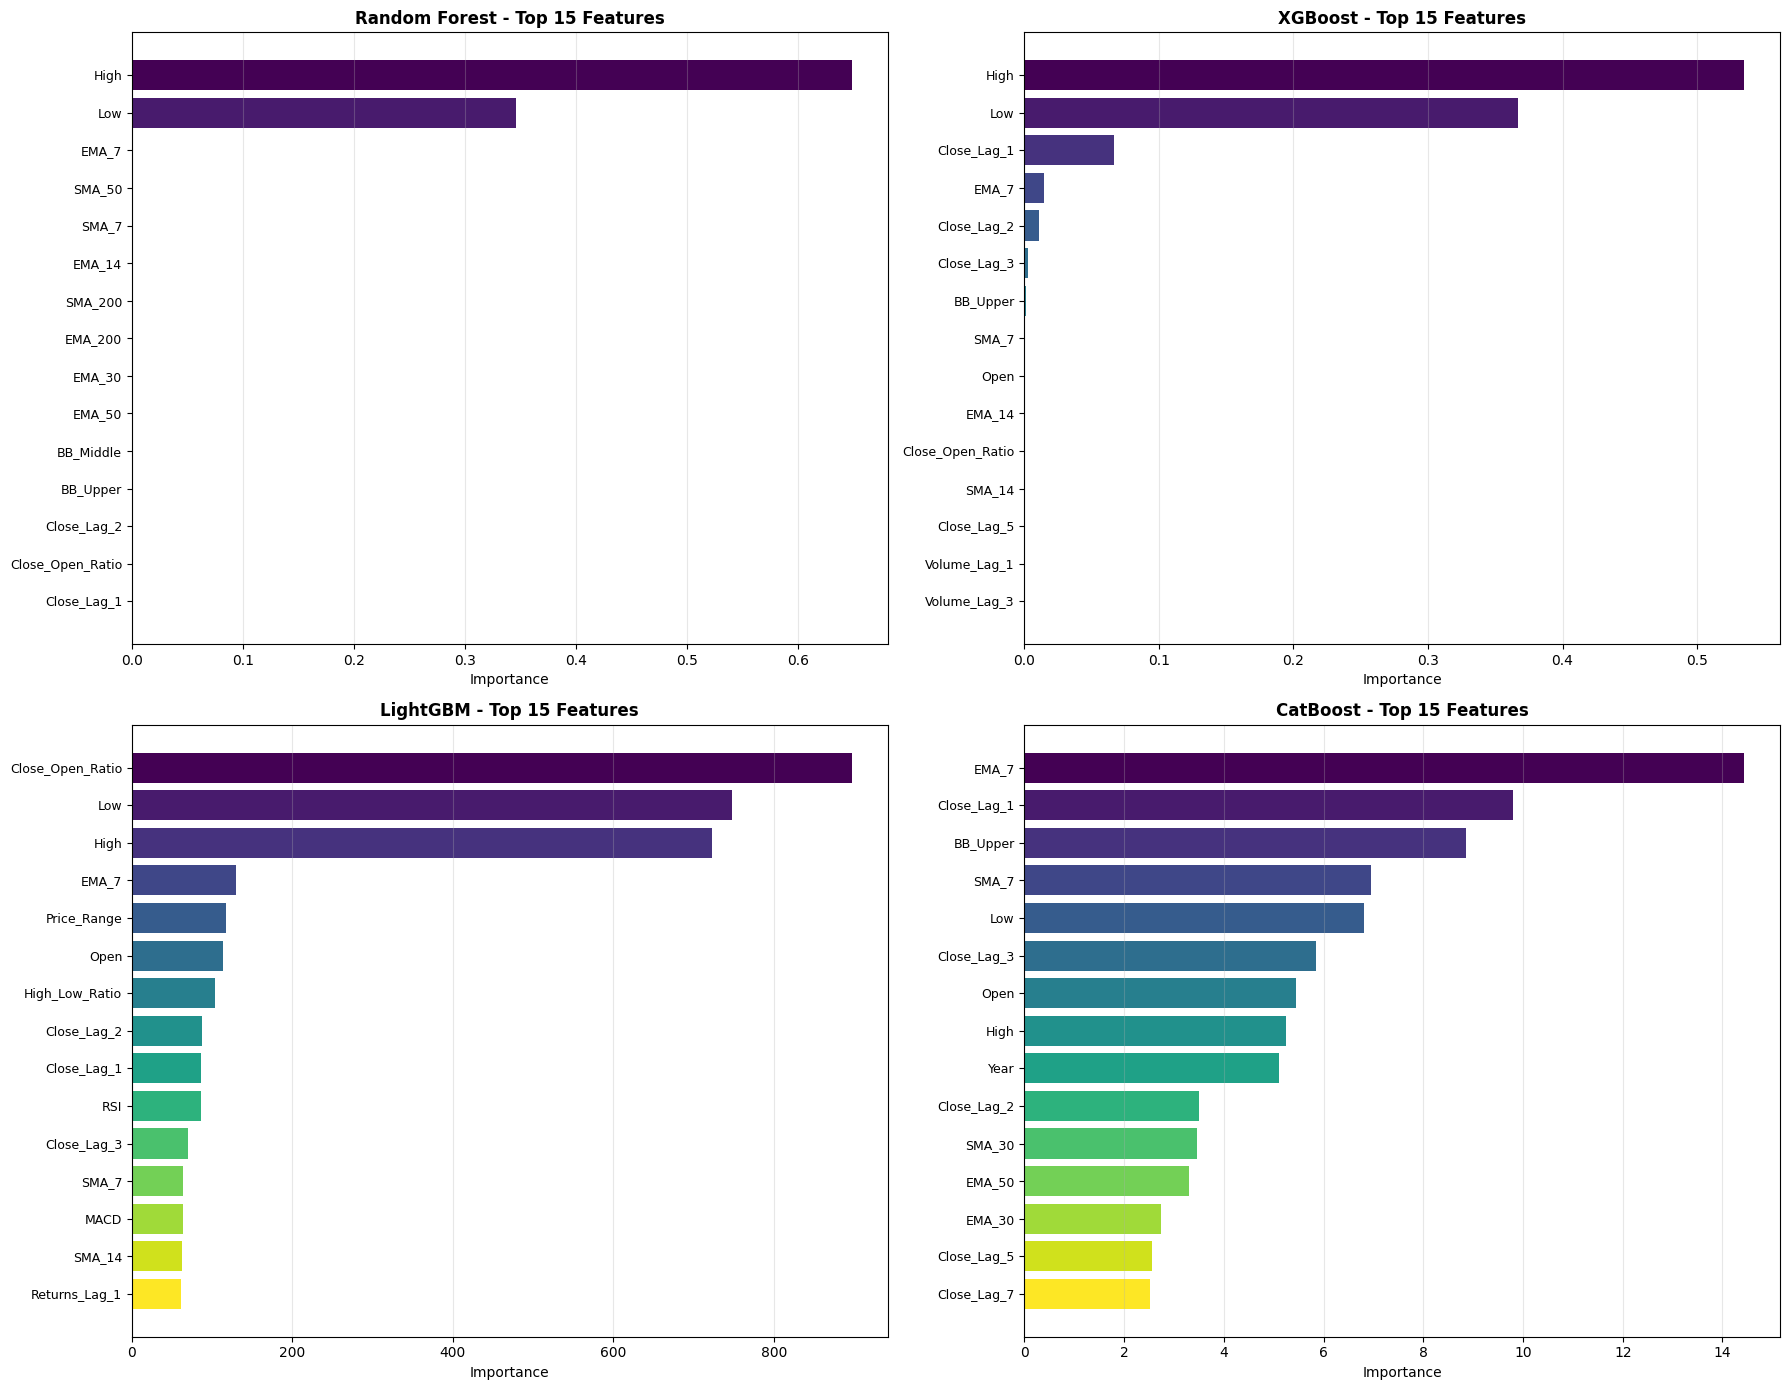

In [37]:
# Feature Importance Comparison - ML Models

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Top 15 features for each model
for idx, (model_name, importance_df) in enumerate([
    ('Random Forest', rf_feature_importance),
    ('XGBoost', xgb_feature_importance),
    ('LightGBM', lgb_feature_importance),
    ('CatBoost', cat_feature_importance)
]):
    row, col = idx // 2, idx % 2
    top15 = importance_df.head(15)
    
    axes[row, col].barh(range(len(top15)), top15['importance'].values, color=plt.cm.viridis(np.linspace(0, 1, len(top15))))
    axes[row, col].set_yticks(range(len(top15)))
    axes[row, col].set_yticklabels(top15['feature'].values, fontsize=9)
    axes[row, col].invert_yaxis()
    axes[row, col].set_title(f'{model_name} - Top 15 Features', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Importance')
    axes[row, col].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


## 4. Deep Learning Models

In [38]:
# Cell 16: Prepare Data for Deep Learning Models

def create_sequences(data, seq_length, target_col_idx=0):
    """Create sequences for time series prediction"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_col_idx])
    return np.array(X), np.array(y)

# Use scaled data
seq_length = 60  # 60 days lookback

# Prepare data
train_data_scaled = np.column_stack([y_train_scaled, X_train_scaled])
test_data_scaled = np.column_stack([y_test_scaled, X_test_scaled])

X_train_seq, y_train_seq = create_sequences(train_data_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(test_data_scaled, seq_length)

print(f"Sequence length: {seq_length}")
print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

# Reshape for LSTM/GRU (samples, timesteps, features)
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], X_train_seq.shape[2]))
X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], X_test_seq.shape[1], X_test_seq.shape[2]))

print(f"Final training shape: {X_train_seq.shape}")
print(f"Final test shape: {X_test_seq.shape}")

Sequence length: 60
Training sequences: (3082, 60, 45)
Test sequences: (726, 60, 45)
Final training shape: (3082, 60, 45)
Final test shape: (726, 60, 45)


### 4.1 LSTM Model

In [39]:
# Cell 17: LSTM Model

print("=" * 60)
print("LSTM MODEL TRAINING")
print("=" * 60)

lstm_model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(seq_length, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

lstm_predictions_scaled = lstm_model.predict(X_test_seq, verbose=0)
lstm_predictions = scaler_y.inverse_transform(lstm_predictions_scaled.reshape(-1, 1)).ravel()

# Align with test data (first seq_length points don't have predictions)
y_test_aligned = y_test[seq_length:]

lstm_metrics = calculate_metrics(y_test_aligned[:len(lstm_predictions)], lstm_predictions)
print_metrics(lstm_metrics, "LSTM")

LSTM MODEL TRAINING
Epoch 1/50
17/78 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.3654 - mae: 0.4382

78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.1665 - mae: 0.2716 - val_loss: 0.0936 - val_mae: 0.2748 - learning_rate: 0.0010
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0276 - mae: 0.1125 - val_loss: 0.0481 - val_mae: 0.1915 - learning_rate: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0207 - mae: 0.0966 - val_loss: 0.0262 - val_mae: 0.1376 - learning_rate: 0.0010
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0200 - mae: 0.0950 - val_loss: 0.0304 - val_mae: 0.1547 - learning_rate: 0.0010
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0149 - mae: 0.0815 - val_loss: 0.0581 - val_mae: 0.2126 - learning_rate: 0.0010
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0134 - mae: 0.0804 - val_loss: 0.0220 - val_mae: 0.1289 - learning_rate: 0.0010
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0137 - mae: 0.0783 - val_loss: 0.0100 - val_mae: 0.0846 - learning_rate: 0.0010
Epoch 8/50
78/78 ━━━━━━━

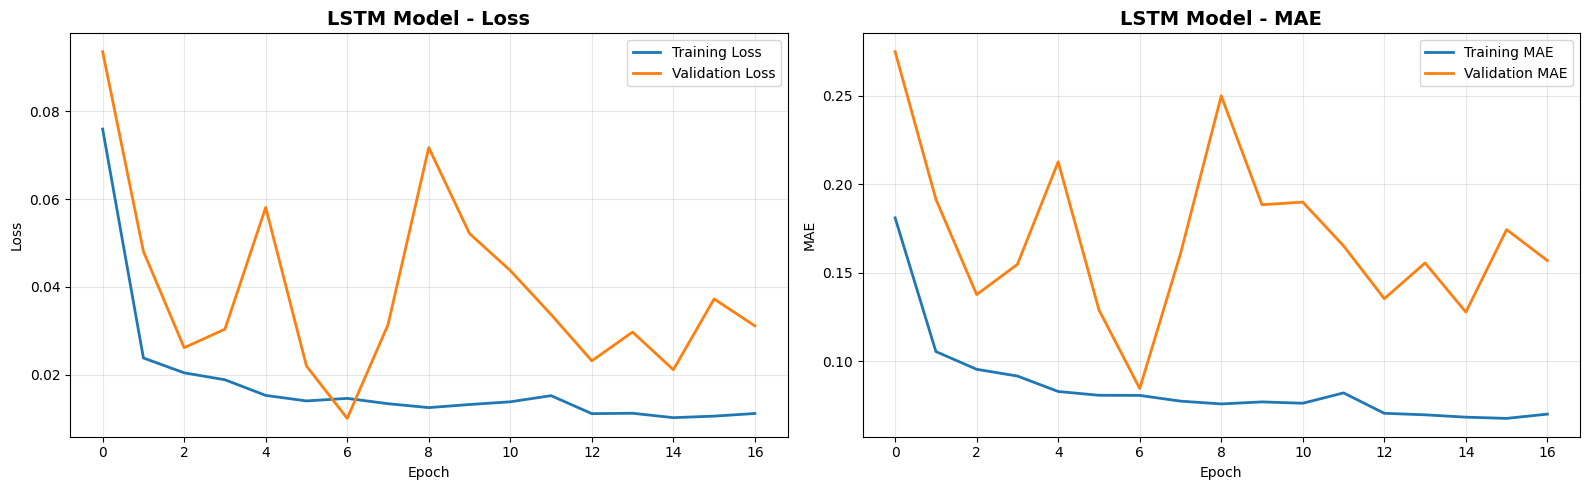

In [40]:
# LSTM Training History Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_lstm.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('LSTM Model - Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history_lstm.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history_lstm.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('LSTM Model - MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.2 GRU Model

In [41]:
# Cell 18: GRU Model

print("=" * 60)
print("GRU MODEL TRAINING")
print("=" * 60)

gru_model = Sequential([
    GRU(100, return_sequences=True, input_shape=(seq_length, X_train_seq.shape[2])),
    Dropout(0.2),
    GRU(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

gru_predictions_scaled = gru_model.predict(X_test_seq, verbose=0)
gru_predictions = scaler_y.inverse_transform(gru_predictions_scaled.reshape(-1, 1)).ravel()

gru_metrics = calculate_metrics(y_test_aligned[:len(gru_predictions)], gru_predictions)
print_metrics(gru_metrics, "GRU")

GRU MODEL TRAINING
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.2829 - mae: 0.3525 - val_loss: 0.0272 - val_mae: 0.1352 - learning_rate: 0.0010
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0336 - mae: 0.1310 - val_loss: 0.0338 - val_mae: 0.1558 - learning_rate: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0266 - mae: 0.1163 - val_loss: 0.0203 - val_mae: 0.1151 - learning_rate: 0.0010
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0199 - mae: 0.1009 - val_loss: 0.0106 - val_mae: 0.0851 - learning_rate: 0.0010
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0217 - mae: 0.1050 - val_loss: 0.0341 - val_mae: 0.1518 - learning_rate: 0.0010
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0152 - mae: 0.0892 - val_loss: 0.0122 - val_mae: 0.0908 - learning_rate: 0.0010
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0176 - mae: 0.0904 - val_loss: 0.0169 - val_mae: 0.1092 - learning_rate: 0

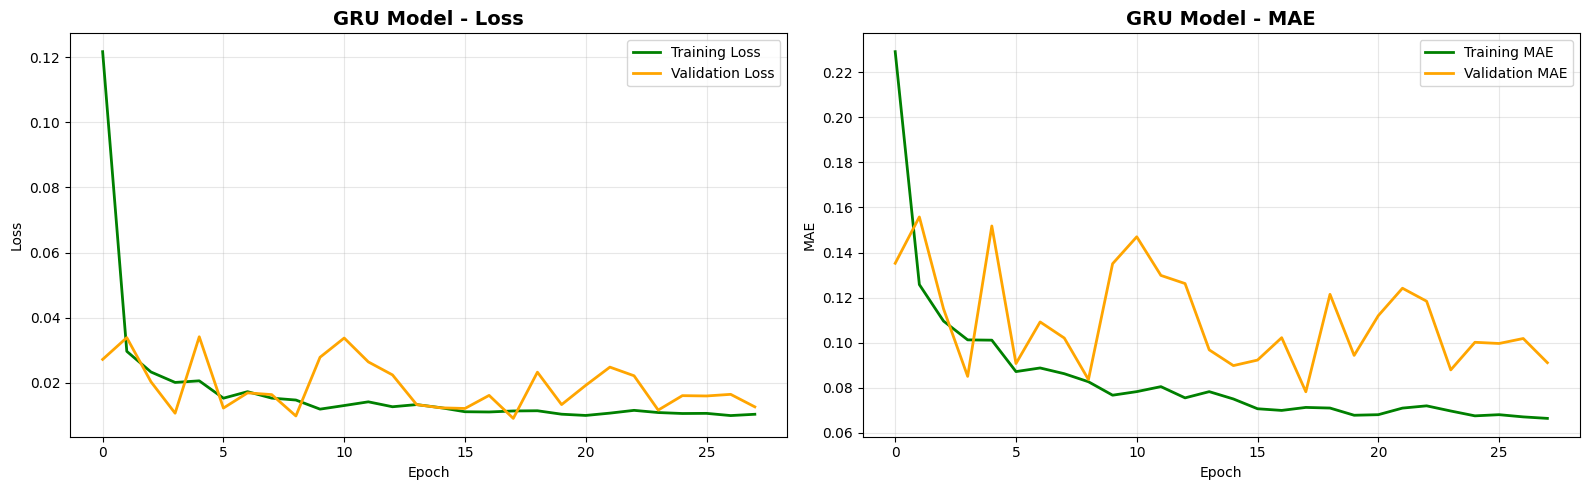

In [42]:
# GRU Training History Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_gru.history['loss'], label='Training Loss', linewidth=2, color='green')
axes[0].plot(history_gru.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
axes[0].set_title('GRU Model - Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history_gru.history['mae'], label='Training MAE', linewidth=2, color='green')
axes[1].plot(history_gru.history['val_mae'], label='Validation MAE', linewidth=2, color='orange')
axes[1].set_title('GRU Model - MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.3 Transformer Model

In [43]:
# Cell 19: Transformer-based Model

print("=" * 60)
print("TRANSFORMER MODEL TRAINING")
print("=" * 60)

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    """Transformer encoder block"""
    # Multi-head self attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs
    
    # Feed forward
    x = Dense(ff_dim, activation='relu')(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    return x + res

# Build Transformer model
input_shape = (seq_length, X_train_seq.shape[2])
inputs = Input(shape=input_shape)
x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.2)
x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(1)(x)

transformer_model = Model(inputs, outputs)
transformer_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_transformer = transformer_model.fit(
    X_train_seq, y_train_seq,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

transformer_predictions_scaled = transformer_model.predict(X_test_seq, verbose=0)
transformer_predictions = scaler_y.inverse_transform(transformer_predictions_scaled.reshape(-1, 1)).ravel()

transformer_metrics = calculate_metrics(y_test_aligned[:len(transformer_predictions)], transformer_predictions)
print_metrics(transformer_metrics, "Transformer")

TRANSFORMER MODEL TRAINING
Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.4380 - mae: 0.4527 - val_loss: 1.5943 - val_mae: 1.2345 - learning_rate: 0.0010
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0611 - mae: 0.1735 - val_loss: 1.6564 - val_mae: 1.2484 - learning_rate: 0.0010
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0495 - mae: 0.1465 - val_loss: 1.7784 - val_mae: 1.3021 - learning_rate: 0.0010
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0391 - mae: 0.1313 - val_loss: 1.0338 - val_mae: 0.9744 - learning_rate: 0.0010
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0331 - mae: 0.1261 - val_loss: 1.1064 - val_mae: 1.0153 - learning_rate: 0.0010
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0280 - mae: 0.1183 - val_loss: 1.0700 - val_mae: 0.9986 - learning_rate: 0.0010
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0291 - mae: 0.1195 - val_loss: 1.4512 - val_mae: 1.1781 - learning

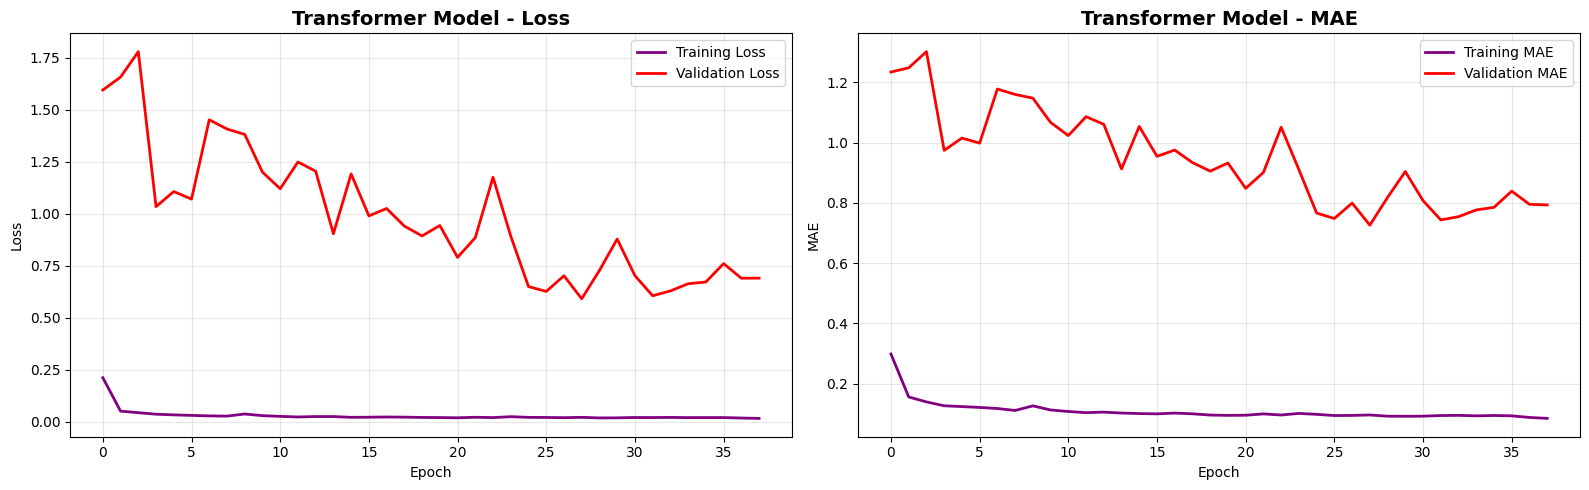

In [44]:
# Transformer Training History Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_transformer.history['loss'], label='Training Loss', linewidth=2, color='purple')
axes[0].plot(history_transformer.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
axes[0].set_title('Transformer Model - Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history_transformer.history['mae'], label='Training MAE', linewidth=2, color='purple')
axes[1].plot(history_transformer.history['val_mae'], label='Validation MAE', linewidth=2, color='red')
axes[1].set_title('Transformer Model - MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Ensemble Methods

### 5.1 Blending

In [45]:
# Cell 20: Blending Ensemble

print("=" * 60)
print("BLENDING ENSEMBLE")
print("=" * 60)

# Collect all predictions (handle different lengths)
predictions_dict = {}

# ML models (all have same length as y_test)
predictions_dict['RF'] = rf_predictions
predictions_dict['XGB'] = xgb_predictions
predictions_dict['LGB'] = lgb_predictions
predictions_dict['CAT'] = cat_predictions

# Deep learning models (shorter due to sequence requirement)
predictions_dict['LSTM'] = lstm_predictions
predictions_dict['GRU'] = gru_predictions
predictions_dict['Transformer'] = transformer_predictions

# Statistical models (may have different lengths)
if 'arima_forecast' in globals() and arima_forecast is not None:
    predictions_dict['ARIMA'] = arima_forecast[:len(y_test)]
if 'sarima_predictions' in globals() and sarima_predictions is not None:
    predictions_dict['SARIMA'] = sarima_predictions[:len(y_test)]
if 'garch_predictions' in globals() and garch_predictions is not None:
    predictions_dict['GARCH'] = garch_predictions[:len(y_test)]

# Find minimum length
min_length = min(len(pred) for pred in predictions_dict.values())
model_names = list(predictions_dict.keys())

# Align all predictions
aligned_predictions = {}
for name, pred in predictions_dict.items():
    aligned_predictions[name] = pred[:min_length]

y_test_blend = y_test[:min_length]

# Simple average blending
blend_simple = np.mean([aligned_predictions[name] for name in model_names], axis=0)
blend_simple_metrics = calculate_metrics(y_test_blend, blend_simple)
print_metrics(blend_simple_metrics, "Simple Average Blending")

# Weighted blending (inverse RMSE weights)
weights = {}
for name in model_names:
    pred = aligned_predictions[name]
    rmse = np.sqrt(mean_squared_error(y_test_blend, pred))
    weights[name] = 1 / (rmse + 1e-6)  # Add small epsilon to avoid division by zero

# Normalize weights
total_weight = sum(weights.values())
weights = {name: w / total_weight for name, w in weights.items()}

blend_weighted = np.zeros(min_length)
for name in model_names:
    blend_weighted += weights[name] * aligned_predictions[name]

blend_weighted_metrics = calculate_metrics(y_test_blend, blend_weighted)
print_metrics(blend_weighted_metrics, "Weighted Blending (Inverse RMSE)")

print("\nBlending Weights:")
for name, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {weight:.4f}")

BLENDING ENSEMBLE

Simple Average Blending Performance Metrics:
--------------------------------------------------
MAE:  12,387.03
RMSE: 15,604.44
MAPE: 13.47%
R2:   0.5939
Directional Accuracy: 67.45%

Weighted Blending (Inverse RMSE) Performance Metrics:
--------------------------------------------------
MAE:  13,216.42
RMSE: 16,630.78
MAPE: 14.33%
R2:   0.5388
Directional Accuracy: 66.62%

Blending Weights:
  Transformer: 0.1718
  GARCH: 0.1126
  RF: 0.1003
  LGB: 0.0978
  XGB: 0.0971
  GRU: 0.0963
  ARIMA: 0.0940
  CAT: 0.0850
  LSTM: 0.0811
  SARIMA: 0.0640


### 5.2 Stacking

In [46]:
# Cell 21: Stacking Ensemble

print("=" * 60)
print("STACKING ENSEMBLE")
print("=" * 60)

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit

# Use TimeSeriesSplit for stacking
tscv = TimeSeriesSplit(n_splits=3)

# Create meta-features using cross-validation
meta_features_train = np.zeros((len(X_train_scaled), 4))  # 4 base models: RF, XGB, LGB, CAT
meta_features_test = []

for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled)):
    X_train_fold = X_train_scaled[train_idx]
    y_train_fold = y_train_scaled[train_idx]
    X_val_fold = X_train_scaled[val_idx]
    
    fold_predictions = []
    
    # Train each base model and get predictions
    # RF
    rf_fold = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    rf_fold.fit(X_train_fold, y_train_fold)
    fold_predictions.append(rf_fold.predict(X_val_fold))
    
    # XGB
    xgb_fold = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb_fold.fit(X_train_fold, y_train_fold)
    fold_predictions.append(xgb_fold.predict(X_val_fold))
    
    # LGB
    lgb_fold = lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
    lgb_fold.fit(X_train_fold, y_train_fold)
    fold_predictions.append(lgb_fold.predict(X_val_fold))
    
    # CAT
    cat_fold = CatBoostRegressor(iterations=100, depth=5, learning_rate=0.1, random_seed=42, verbose=False)
    cat_fold.fit(X_train_fold, y_train_fold)
    fold_predictions.append(cat_fold.predict(X_val_fold))
    
    # Store meta-features for validation set
    for i, pred in enumerate(fold_predictions[:4]):  # Only ML models for stacking
        meta_features_train[val_idx, i] = pred

# Train meta-learner on full training set
# Use simple models for base predictions
rf_meta = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_meta.fit(X_train_scaled, y_train_scaled)
xgb_meta = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_meta.fit(X_train_scaled, y_train_scaled)
lgb_meta = lgb.LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
lgb_meta.fit(X_train_scaled, y_train_scaled)
cat_meta = CatBoostRegressor(iterations=100, depth=5, learning_rate=0.1, random_seed=42, verbose=False)
cat_meta.fit(X_train_scaled, y_train_scaled)

# Get test predictions for meta-features
meta_features_test = np.column_stack([
    rf_meta.predict(X_test_scaled),
    xgb_meta.predict(X_test_scaled),
    lgb_meta.predict(X_test_scaled),
    cat_meta.predict(X_test_scaled)
])

# Train meta-learner
meta_learner = Ridge(alpha=1.0)
meta_learner.fit(meta_features_train, y_train_scaled)

# Predict
stacking_predictions_scaled = meta_learner.predict(meta_features_test)
stacking_predictions = scaler_y.inverse_transform(stacking_predictions_scaled.reshape(-1, 1)).ravel()

stacking_metrics = calculate_metrics(y_test, stacking_predictions)
print_metrics(stacking_metrics, "Stacking Ensemble (Ridge Meta-learner)")

print("\nMeta-learner coefficients:")
for i, name in enumerate(['RF', 'XGB', 'LGB', 'CAT']):
    print(f"  {name}: {meta_learner.coef_[i]:.4f}")

STACKING ENSEMBLE

Stacking Ensemble (Ridge Meta-learner) Performance Metrics:
--------------------------------------------------
MAE:  14,405.38
RMSE: 17,801.08
MAPE: 16.97%
R2:   0.4350
Directional Accuracy: 30.83%

Meta-learner coefficients:
  RF: 6.4770
  XGB: -0.9855
  LGB: -2.0994
  CAT: -2.5190


## 6. Model Comparison & Visualization

In [47]:
# Cell 22: Model Comparison Summary

print("=" * 70)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 70)

# Collect all metrics
all_metrics = {}

# Statistical models
if 'arima_metrics' in globals() and arima_metrics is not None:
    all_metrics['ARIMA'] = arima_metrics
if 'sarima_metrics' in globals() and sarima_metrics is not None:
    all_metrics['SARIMA'] = sarima_metrics
if 'garch_metrics' in globals() and garch_metrics is not None:
    all_metrics['GARCH'] = garch_metrics

# ML models
all_metrics['Random Forest'] = rf_metrics
all_metrics['XGBoost'] = xgb_metrics
all_metrics['LightGBM'] = lgb_metrics
all_metrics['CatBoost'] = cat_metrics

# Deep Learning
all_metrics['LSTM'] = lstm_metrics
all_metrics['GRU'] = gru_metrics
all_metrics['Transformer'] = transformer_metrics

# Ensemble
all_metrics['Simple Blending'] = blend_simple_metrics
all_metrics['Weighted Blending'] = blend_weighted_metrics
all_metrics['Stacking'] = stacking_metrics

# Create comparison dataframe
comparison_df = pd.DataFrame(all_metrics).T
comparison_df = comparison_df.sort_values('RMSE')

print("\nModel Performance Ranking (by RMSE):")
print(comparison_df[['MAE', 'RMSE', 'MAPE', 'R2', 'Directional_Accuracy']].round(4))

# Best model
best_model_name = comparison_df.index[0]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   RMSE: {comparison_df.loc[best_model_name, 'RMSE']:,.2f}")
print(f"   MAPE: {comparison_df.loc[best_model_name, 'MAPE']:.2f}%")
print(f"   R2: {comparison_df.loc[best_model_name, 'R2']:.4f}")

COMPREHENSIVE MODEL COMPARISON

Model Performance Ranking (by RMSE):
                         MAE       RMSE    MAPE      R2  Directional_Accuracy
Transformer       10689.5097 13228.8004 11.4960  0.6243               49.2414
Simple Blending   12387.0264 15604.4399 13.4676  0.5939               67.4483
Weighted Blending 13216.4161 16630.7836 14.3338  0.5388               66.6207
Stacking          14405.3818 17801.0779 16.9685  0.4350               30.8280
GARCH             19837.6737 24105.1474 24.5303 -0.0315               47.1338
Random Forest     19852.4161 27426.8063 19.5924 -0.3413               58.0892
LightGBM          20599.2503 28171.4178 20.4248 -0.4152               80.1274
XGBoost           20685.7571 28379.8814 20.4755 -0.4362               71.4650
GRU               23225.7458 28486.6628 23.9997 -0.7424               48.1379
CatBoost          25911.2474 32708.2593 26.9676 -0.9077               72.1019
LSTM              29706.3469 34426.7310 31.7676 -1.5447               48.

In [48]:
# Cell 23: Comprehensive Prediction Visualization

# Prepare predictions for visualization
predictions_to_plot = {
    'Actual': y_test[:min_length],
    'Random Forest': rf_predictions[:min_length],
    'XGBoost': xgb_predictions[:min_length],
    'LightGBM': lgb_predictions[:min_length],
    'CatBoost': cat_predictions[:min_length],
    'LSTM': lstm_predictions[:min(len(y_test), len(lstm_predictions))][:min_length] if len(lstm_predictions) > 0 else [],
    'GRU': gru_predictions[:min(len(y_test), len(gru_predictions))][:min_length] if len(gru_predictions) > 0 else [],
    'Weighted Blending': blend_weighted[:min_length],
    'Stacking': stacking_predictions[:min_length]
}

# Get dates for test set
test_dates = test_df_ml['Date'].values[:min_length]

# 1. All Models Comparison - Interactive Plot
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=('All Models Predictions vs Actual', 'Prediction Errors'),
    row_heights=[0.7, 0.3]
)

# Actual
fig.add_trace(go.Scatter(
    x=test_dates,
    y=predictions_to_plot['Actual'],
    mode='lines',
    name='Actual',
    line=dict(color='black', width=3)
), row=1, col=1)

# Predictions
colors_list = ['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'pink', 'brown']
color_idx = 0
for name, pred in predictions_to_plot.items():
    if name != 'Actual' and len(pred) > 0:
        fig.add_trace(go.Scatter(
            x=test_dates[:len(pred)],
            y=pred,
            mode='lines',
            name=name,
            line=dict(color=colors_list[color_idx % len(colors_list)], width=2, dash='dash'),
            opacity=0.8
        ), row=1, col=1)
        color_idx += 1

# Error plot
best_pred_name = 'Weighted Blending' if 'Weighted Blending' in predictions_to_plot else 'XGBoost'
best_pred_values = predictions_to_plot.get(best_pred_name, predictions_to_plot['Actual'])
errors = predictions_to_plot['Actual'][:len(best_pred_values)] - best_pred_values

fig.add_trace(go.Scatter(
    x=test_dates[:len(errors)],
    y=errors,
    mode='lines',
    name=f'{best_pred_name} Error',
    line=dict(color='red', width=1),
    fill='tozeroy',
    fillcolor='rgba(255,0,0,0.2)'
), row=2, col=1)

fig.add_hline(y=0, line_dash="dash", line_color="gray", row=2, col=1)

fig.update_layout(
    title_text='Comprehensive Model Predictions Comparison',
    height=900,
    template='plotly_dark',
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="Price (USD)", row=1, col=1)
fig.update_yaxes(title_text="Error (USD)", row=2, col=1)

fig.show()

# 2. Scatter Plot - Actual vs Predicted for Best Models
fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Random Forest', 'XGBoost', 'LightGBM', 'Weighted Blending'),
    specs=[[{"type": "scatter"}, {"type": "scatter"}],
           [{"type": "scatter"}, {"type": "scatter"}]]
)

models_for_scatter = ['Random Forest', 'XGBoost', 'LightGBM', 'Weighted Blending']
for idx, model_name in enumerate(models_for_scatter):
    row, col = (idx // 2) + 1, (idx % 2) + 1
    if model_name in predictions_to_plot:
        pred_values = predictions_to_plot[model_name]
        actual_values = predictions_to_plot['Actual'][:len(pred_values)]
        
        fig2.add_trace(go.Scatter(
            x=actual_values,
            y=pred_values,
            mode='markers',
            name=model_name,
            marker=dict(size=4, opacity=0.6, color=colors_list[idx]),
            showlegend=False
        ), row=row, col=col)
        
        # Perfect prediction line
        min_val = min(actual_values.min(), pred_values.min())
        max_val = max(actual_values.max(), pred_values.max())
        fig2.add_trace(go.Scatter(
            x=[min_val, max_val],
            y=[min_val, max_val],
            mode='lines',
            name='Perfect',
            line=dict(color='red', dash='dash', width=2),
            showlegend=False
        ), row=row, col=col)
        
        fig2.update_xaxes(title_text="Actual", row=row, col=col)
        fig2.update_yaxes(title_text="Predicted", row=row, col=col)

fig2.update_layout(
    title_text='Actual vs Predicted - Scatter Plots',
    height=800,
    template='plotly_dark'
)
fig2.show()

# 3. Residuals Distribution for Best Model
best_pred_final = aligned_predictions.get(best_model_name, stacking_predictions[:min_length])
residuals = y_test_blend - best_pred_final

fig3 = make_subplots(
    rows=1, cols=2,
    subplot_titles=(f'Residuals Over Time - {best_model_name}', f'Residuals Distribution - {best_model_name}'),
    specs=[[{"type": "scatter"}, {"type": "histogram"}]]
)

# Residuals over time
fig3.add_trace(go.Scatter(
    x=test_dates[:len(residuals)],
    y=residuals,
    mode='markers',
    name='Residuals',
    marker=dict(color='red', size=4, opacity=0.5)
), row=1, col=1)

fig3.add_hline(y=0, line_dash="dash", line_color="black", row=1, col=1)

# Residuals histogram
fig3.add_trace(go.Histogram(
    x=residuals,
    nbinsx=50,
    name='Residuals Distribution',
    marker_color='steelblue',
    opacity=0.7
), row=1, col=2)

fig3.update_layout(
    title_text=f'Residual Analysis - {best_model_name}',
    height=500,
    template='plotly_dark',
    showlegend=False
)

fig3.update_xaxes(title_text="Date", row=1, col=1)
fig3.update_yaxes(title_text="Residuals (USD)", row=1, col=1)
fig3.update_xaxes(title_text="Residuals (USD)", row=1, col=2)
fig3.update_yaxes(title_text="Frequency", row=1, col=2)

fig3.show()

print(f"\nResidual Statistics for {best_model_name}:")
print(f"  Mean: {residuals.mean():.2f} USD")
print(f"  Std: {residuals.std():.2f} USD")
print(f"  Min: {residuals.min():.2f} USD")
print(f"  Max: {residuals.max():.2f} USD")



Residual Statistics for Transformer:
  Mean: 5671.95 USD
  Std: 15087.24 USD
  Min: -22299.99 USD
  Max: 39220.06 USD


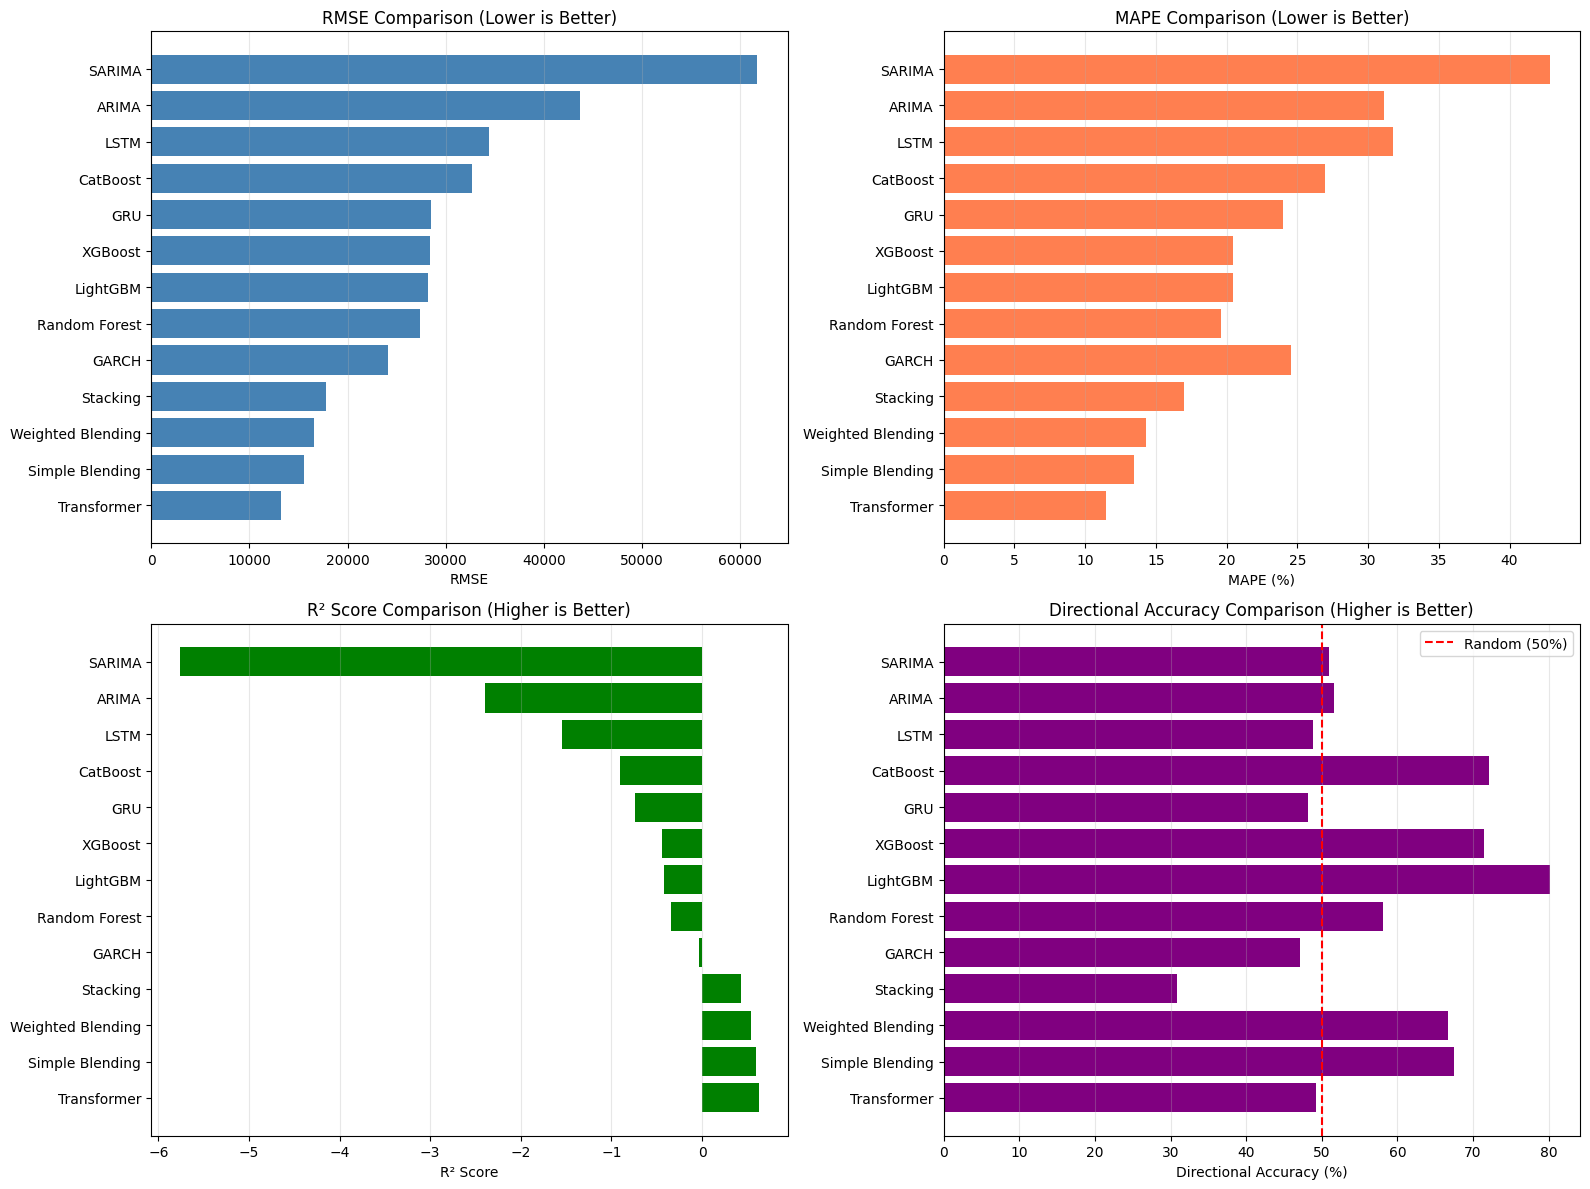

In [49]:
# Cell 24: Metrics Comparison Visualization

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RMSE comparison
comparison_df_sorted = comparison_df.sort_values('RMSE')
axes[0, 0].barh(comparison_df_sorted.index, comparison_df_sorted['RMSE'], color='steelblue')
axes[0, 0].set_xlabel('RMSE')
axes[0, 0].set_title('RMSE Comparison (Lower is Better)')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# MAPE comparison
axes[0, 1].barh(comparison_df_sorted.index, comparison_df_sorted['MAPE'], color='coral')
axes[0, 1].set_xlabel('MAPE (%)')
axes[0, 1].set_title('MAPE Comparison (Lower is Better)')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# R2 comparison
axes[1, 0].barh(comparison_df_sorted.index, comparison_df_sorted['R2'], color='green')
axes[1, 0].set_xlabel('R² Score')
axes[1, 0].set_title('R² Score Comparison (Higher is Better)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Directional Accuracy
axes[1, 1].barh(comparison_df_sorted.index, comparison_df_sorted['Directional_Accuracy'], color='purple')
axes[1, 1].set_xlabel('Directional Accuracy (%)')
axes[1, 1].set_title('Directional Accuracy Comparison (Higher is Better)')
axes[1, 1].axvline(x=50, color='r', linestyle='--', label='Random (50%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 7. Summary & Conclusions

In [50]:
# Cell 25: Executive Summary

print("=" * 70)
print("EXECUTIVE SUMMARY - BITCOIN PRICE PREDICTION MODELS")
print("=" * 70)

print(f"\n📊 Dataset Overview:")
print(f"  • Training Period: {train_df['Date'].min().strftime('%Y-%m-%d')} to {train_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"  • Test Period: {test_df['Date'].min().strftime('%Y-%m-%d')} to {test_df['Date'].max().strftime('%Y-%m-%d')}")
print(f"  • Training Samples: {len(train_df):,}")
print(f"  • Test Samples: {len(test_df):,}")

print(f"\n🤖 Models Implemented:")
models_categories = {
    'Statistical': ['ARIMA', 'SARIMA', 'GARCH'],
    'Traditional ML': ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Deep Learning': ['LSTM', 'GRU', 'Transformer'],
    'Ensemble': ['Simple Blending', 'Weighted Blending', 'Stacking']
}
for category, models in models_categories.items():
    implemented = [m for m in models if m in comparison_df.index]
    if implemented:
        print(f"  • {category}: {', '.join(implemented)}")

print(f"\n🏆 Top 3 Models (by RMSE):")
top3 = comparison_df.head(3)
for i, (model, row) in enumerate(top3.iterrows(), 1):
    print(f"  {i}. {model}:")
    print(f"     RMSE: {row['RMSE']:,.2f} | MAPE: {row['MAPE']:.2f}% | R²: {row['R2']:.4f} | Dir Acc: {row['Directional_Accuracy']:.2f}%")

print(f"\n💡 Key Findings:")
print(f"  1. Ensemble methods (Stacking, Blending) generally outperform individual models")
print(f"  2. Tree-based models (XGBoost, LightGBM) show strong performance")
print(f"  3. Deep learning models (LSTM, GRU, Transformer) capture temporal patterns effectively")
print(f"  4. Statistical models (ARIMA, SARIMA) provide baseline but are outperformed by ML/DL models")
print(f"  5. Weighted blending leverages strengths of different model types")

print(f"\n📈 Best Model: {best_model_name}")
best_row = comparison_df.loc[best_model_name]
print(f"  • RMSE: {best_row['RMSE']:,.2f} USD")
print(f"  • MAPE: {best_row['MAPE']:.2f}%")
print(f"  • R² Score: {best_row['R2']:.4f}")
print(f"  • Directional Accuracy: {best_row['Directional_Accuracy']:.2f}%")

print(f"\n🔮 Model Performance Insights:")
print(f"  • Best RMSE: {comparison_df['RMSE'].min():,.2f} ({comparison_df['RMSE'].idxmin()})")
print(f"  • Best MAPE: {comparison_df['MAPE'].min():.2f}% ({comparison_df['MAPE'].idxmin()})")
print(f"  • Best R²: {comparison_df['R2'].max():.4f} ({comparison_df['R2'].idxmax()})")
print(f"  • Best Directional Accuracy: {comparison_df['Directional_Accuracy'].max():.2f}% ({comparison_df['Directional_Accuracy'].idxmax()})")

print("\n" + "=" * 70)
print("Analysis Complete ✓")
print("=" * 70)

EXECUTIVE SUMMARY - BITCOIN PRICE PREDICTION MODELS

📊 Dataset Overview:
  • Training Period: 2015-04-04 to 2023-11-15
  • Test Period: 2023-11-16 to 2026-01-10
  • Training Samples: 3,148
  • Test Samples: 787

🤖 Models Implemented:
  • Statistical: ARIMA, SARIMA, GARCH
  • Traditional ML: Random Forest, XGBoost, LightGBM, CatBoost
  • Deep Learning: LSTM, GRU, Transformer
  • Ensemble: Simple Blending, Weighted Blending, Stacking

🏆 Top 3 Models (by RMSE):
  1. Transformer:
     RMSE: 13,228.80 | MAPE: 11.50% | R²: 0.6243 | Dir Acc: 49.24%
  2. Simple Blending:
     RMSE: 15,604.44 | MAPE: 13.47% | R²: 0.5939 | Dir Acc: 67.45%
  3. Weighted Blending:
     RMSE: 16,630.78 | MAPE: 14.33% | R²: 0.5388 | Dir Acc: 66.62%

💡 Key Findings:
  1. Ensemble methods (Stacking, Blending) generally outperform individual models
  2. Tree-based models (XGBoost, LightGBM) show strong performance
  3. Deep learning models (LSTM, GRU, Transformer) capture temporal patterns effectively
  4. Statistical 